In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ks_2samp
from scipy.stats import norm
import sys
sys.path.insert(0,'../g3algo/')
from center_binned_stats import center_binned_stats as cbs

In [2]:
g3green = '#105f47'
g3shade = '#1b9e77'
foforange = '#d95f02'

In [3]:
def uniqstat(grpn, ydata, func):
    assert callable(func),"Func must be callable for array of 1D size."
    uniqN = np.unique(grpn)
    binstat = np.zeros_like(uniqN)
    for ii,NN in enumerate(uniqN):
        sel = np.where(grpn==NN)
        binstat[ii]=func(ydata[sel])
    return [binstat,uniqN]

def KS_in_bins(x1,y1,x2,y2,alt='two-sided'):
    uniqx1 = np.unique(x1)
    uniqx2 = np.unique(x2)
    uniqx12 = np.intersect1d(uniqx1,uniqx2)
    kspval = np.zeros_like(uniqx12)
    for ii,NN in enumerate(uniqx12):
        sel1 = np.where(x1==NN)
        sel2 = np.where(x2==NN)
        _, pv = ks_2samp(y1[sel1],y2[sel2],alternative=alt)
        kspval[ii]=pv
    return uniqx12, kspval

In [4]:
eco = pd.read_csv("/srv/two/cielo/zhutchen/database/make_ECO_DR3/ECODR3_assubmitted.csv")

In [5]:
g3 = eco[(eco.absrmag<-17.33)&(eco.g3grpcz>3000)&(eco.g3grpcz<7000)]
g3 = g3.groupby('g3grp').first()
fof = eco[(eco.absrmag<-17.33)&(eco.grpcz>3000)&(eco.grpcz<7000)]
fof = fof.groupby('grp').first()
print(len(g3),len(fof))

6575 6718


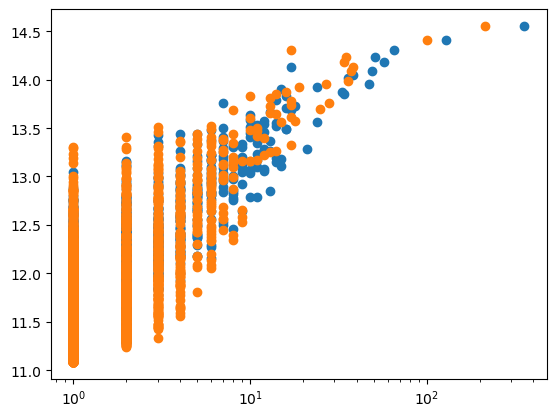

In [6]:
plt.figure()
plt.scatter(g3.g3grpngi+g3.g3grpndw,g3.g3logmhvir)
plt.scatter(fof.grpn,fof.logmhvir)
plt.xscale('log')
plt.show()

In [7]:
g3grpn = (g3.g3grpngi+g3.g3grpndw).to_numpy()
g3logmh = g3.g3logmhvir.to_numpy()
fofgrpn = fof.grpn.to_numpy()
foflogmh = fof.logmhvir.to_numpy()

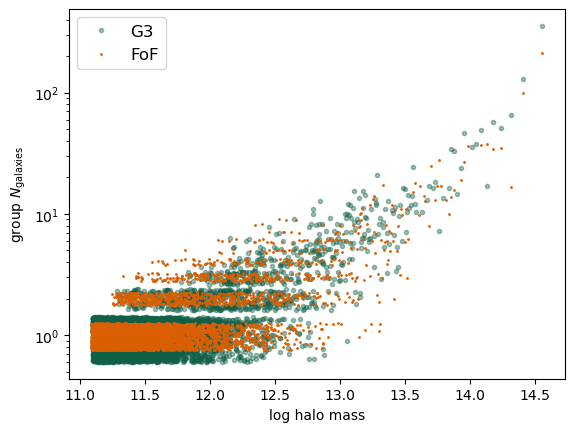

In [8]:
plt.figure()
plt.plot(g3logmh,g3grpn+np.random.uniform(-0.4,0.4,len(g3grpn)),'.',label='G3',alpha=0.4,color=g3green)
plt.plot(foflogmh,fofgrpn+np.random.uniform(-0.25,0.25,len(fofgrpn)),'.',markersize=2,label='FoF',color=foforange)
plt.xlabel("log halo mass")
plt.ylabel(r"group $N_{\rm galaxies}$")
plt.legend(loc='best',fontsize=12)
plt.yscale('log')

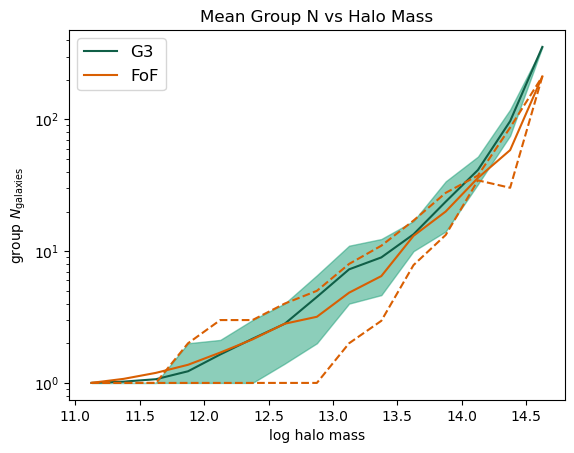

In [9]:
hmbins = np.arange(11,15,0.25)

plt.figure()
meang3grpn, binc, _, _ = cbs(g3logmh,g3grpn,np.mean,bins=hmbins)
perc16_g3grpn, binc, _, _ = cbs(g3logmh,g3grpn,lambda x:np.percentile(x,16),bins=hmbins)
perc84_g3grpn, binc, _, _ = cbs(g3logmh,g3grpn,lambda x:np.percentile(x,84),bins=hmbins)
plt.fill_between(binc,perc16_g3grpn,perc84_g3grpn,alpha=0.5,color=g3shade)
plt.plot(binc,meang3grpn,label='G3',color=g3green)

meanfofgrpn, binc, _, _ = cbs(foflogmh,fofgrpn,'mean',bins=hmbins)
perc16_fofgrpn, binc, _, _ = cbs(foflogmh,fofgrpn,lambda x:np.percentile(x,16),bins=hmbins)
perc84_fofgrpn, binc, _, _ = cbs(foflogmh,fofgrpn,lambda x:np.percentile(x,84),bins=hmbins)
#plt.fill_between(binc,perc16_fofgrpn,perc84_fofgrpn,alpha=0.2)
plt.plot(binc,perc16_fofgrpn,color=foforange,ls='--')
plt.plot(binc,perc84_fofgrpn,color=foforange,ls='--')
plt.plot(binc,meanfofgrpn,label='FoF',color=foforange)
plt.title("Mean Group N vs Halo Mass")

plt.xlabel("log halo mass")
plt.ylabel(r"group $N_{\rm galaxies}$")
plt.legend(loc='best',fontsize=12)
plt.yscale('log')

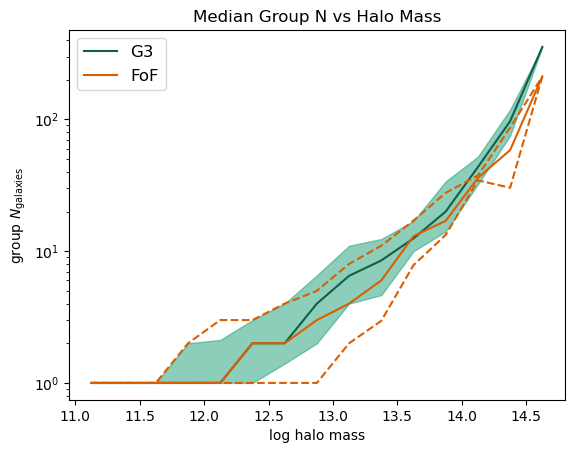

In [10]:
hmbins = np.arange(11,15,0.25)

plt.figure()
mediang3grpn, binc, _, _ = cbs(g3logmh,g3grpn,np.median,bins=hmbins)
perc16_g3grpn, binc, _, _ = cbs(g3logmh,g3grpn,lambda x:np.percentile(x,16),bins=hmbins)
perc84_g3grpn, binc, _, _ = cbs(g3logmh,g3grpn,lambda x:np.percentile(x,84),bins=hmbins)
plt.fill_between(binc,perc16_g3grpn,perc84_g3grpn,alpha=0.5,color=g3shade)
plt.plot(binc,mediang3grpn,label='G3',color=g3green)

medianfofgrpn, binc, _, _ = cbs(foflogmh,fofgrpn,'median',bins=hmbins)
perc16_fofgrpn, binc, _, _ = cbs(foflogmh,fofgrpn,lambda x:np.percentile(x,16),bins=hmbins)
perc84_fofgrpn, binc, _, _ = cbs(foflogmh,fofgrpn,lambda x:np.percentile(x,84),bins=hmbins)
#plt.fill_between(binc,perc16_fofgrpn,perc84_fofgrpn,alpha=0.2)
plt.plot(binc,perc16_fofgrpn,color=foforange,ls='--')
plt.plot(binc,perc84_fofgrpn,color=foforange,ls='--')
plt.plot(binc,medianfofgrpn,label='FoF',color=foforange)
plt.title("Median Group N vs Halo Mass")

plt.xlabel("log halo mass")
plt.ylabel(r"group $N_{\rm galaxies}$")
plt.legend(loc='best',fontsize=12)
plt.yscale('log')

1.0915837441112353
3.8461316101452407
1.7987247969518227
2.3843675634492083


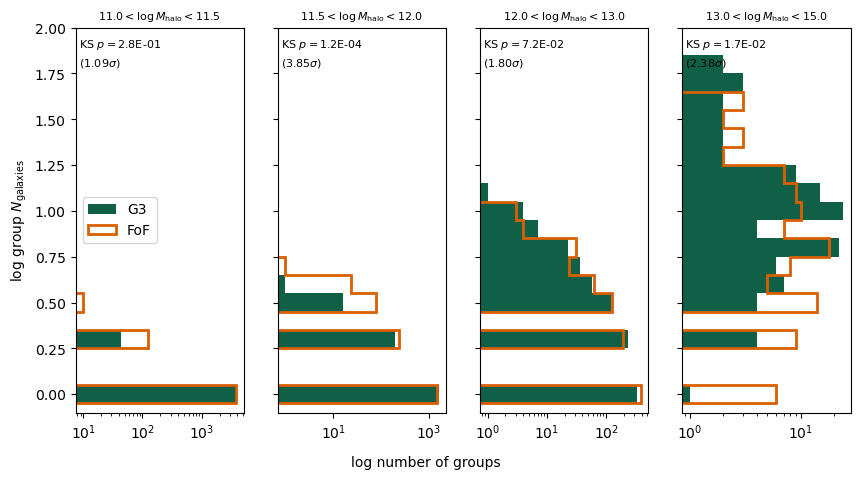

In [11]:
hmbins = [11,11.5,12,13,15]#np.arange(11,14.5,0.5)
mediang3grpn, binc, binedges, _ = cbs(g3logmh,g3grpn,np.median,bins=hmbins)
maxN = len(binc)

fig2, axs = plt.subplots(ncols=maxN,figsize=(10,5),sharey=True)
loggrpnbinv = np.arange(-0.05,2,0.1)#np.arange(0.5,40.5,1)
for ii in range(0,maxN):
    g3sel = (g3logmh>binedges[ii])&(g3logmh<binedges[ii+1])
    axs[ii].hist(np.log10(g3grpn[g3sel]),color='#105f47',bins=loggrpnbinv, label='G3',orientation='horizontal')
    fofsel = (foflogmh>binedges[ii])&(foflogmh<binedges[ii+1])
    axs[ii].hist(np.log10(fofgrpn[fofsel]), color='#d95f02',histtype='step',bins=loggrpnbinv, linewidth=2,label='FoF',\
                orientation='horizontal')
    axs[ii].set_ylim(-0.1,2)
    _, pv = ks_2samp(np.log10(g3grpn[g3sel]),np.log10(fofgrpn[fofsel]))
    sigval = norm.ppf(1-(pv)/2.)
    print(sigval)
    axs[ii].annotate(r'KS $p=$'+'{:.1E}'.format(pv), xy=(0.02,0.95), xycoords='axes fraction',fontsize=8)
    axs[ii].annotate(r"({:0.2f}".format(sigval)+r"$\sigma$)", xy=(0.02,0.9), xycoords='axes fraction',fontsize=8)
    axs[ii].set_title(str(binedges[ii])+r"$<\log M_{\rm halo}<$"+str(binedges[ii+1]),fontsize=8)
    if ii<(maxN):
        axs[ii].set_xscale('log')
    
axs[0].set_ylabel(r"log group $N_{\rm galaxies}$")
axs[0].legend(loc='center left')
#axs[maxN-1].set_xlim(0,10)

fig2.text(0.4,0.003,"log number of groups")
plt.show()

1.0915837441112353
3.8461316101452407
1.7987247969518227
2.3843675634492083


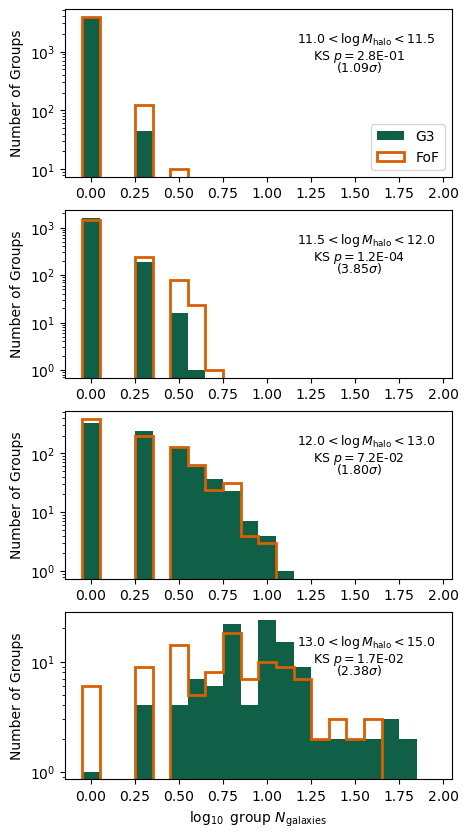

In [12]:
hmbins = [11,11.5,12,13,15]#np.arange(11,14.5,0.5)
mediang3grpn, binc, binedges, _ = cbs(g3logmh,g3grpn,np.median,bins=hmbins)
maxN = len(binc)

fig2, axs = plt.subplots(nrows=maxN,figsize=(5,10))#,sharex=True)
loggrpnbinv = np.arange(-0.05,2,0.1)#np.arange(0.5,40.5,1)
for ii in range(0,maxN):
    g3sel = (g3logmh>binedges[ii])&(g3logmh<binedges[ii+1])
    axs[ii].hist(np.log10(g3grpn[g3sel]),color='#105f47',bins=loggrpnbinv, label='G3',orientation='vertical')
    fofsel = (foflogmh>binedges[ii])&(foflogmh<binedges[ii+1])
    axs[ii].hist(np.log10(fofgrpn[fofsel]), color='#d95f02',histtype='step',bins=loggrpnbinv, linewidth=2,label='FoF',\
                orientation='vertical')
    #axs[ii].set_ylim(-0.1,2)
    _, pv = ks_2samp(np.log10(g3grpn[g3sel]),np.log10(fofgrpn[fofsel]))
    sigval = norm.ppf(1-(pv)/2.)
    print(sigval)
    axs[ii].annotate(r'KS $p=$'+'{:.1E}'.format(pv), xy=(0.64,0.7), xycoords='axes fraction',fontsize=9)
    axs[ii].annotate(r"({:0.2f}".format(sigval)+r"$\sigma$)", xy=(0.7,0.63), xycoords='axes fraction',fontsize=9)
    axs[ii].annotate(str(binedges[ii])+r"$<\log M_{\rm halo}<$"+str(binedges[ii+1]),\
                     xy=(0.6,0.8),xycoords='axes fraction',fontsize=9)
    if ii<(maxN):
        axs[ii].set_yscale('log')
    axs[ii].set_ylabel("Number of Groups")
    
#axs[0].set_ylabel(r"log group $N_{\rm galaxies}$")
axs[0].legend(loc='lower right')
#axs[maxN-1].set_xlim(0,10)

axs[-1].set_xlabel(r"$\log_{10}$ group $N_{\rm galaxies}$")
plt.savefig("../figures/ECO_HOD.pdf",dpi=300)
plt.show()

1.0915837441112353
3.8461316101452407
1.7987247969518227
2.3843675634492083


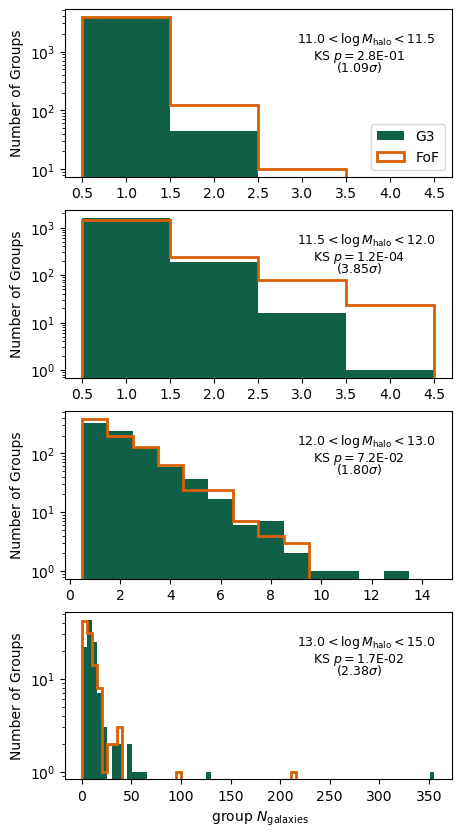

In [28]:
hmbins = [11,11.5,12,13,15]#np.arange(11,14.5,0.5)
mediang3grpn, binc, binedges, _ = cbs(g3logmh,g3grpn,np.median,bins=hmbins)
maxN = len(binc)

binvlist = [np.arange(0.5,5.5,1),np.arange(0.5,5.5,1),np.arange(0.5,15.5,1),\
           np.arange(0.5,360.5,5)]

fig2, axs = plt.subplots(nrows=maxN,figsize=(5,10))#,sharex=True)
loggrpnbinv = np.arange(-0.05,2,0.1)#np.arange(0.5,40.5,1)
for ii in range(0,maxN):
    g3sel = (g3logmh>binedges[ii])&(g3logmh<binedges[ii+1])
    axs[ii].hist((g3grpn[g3sel]),color='#105f47',bins=binvlist[ii], label='G3',orientation='vertical')
    fofsel = (foflogmh>binedges[ii])&(foflogmh<binedges[ii+1])
    axs[ii].hist((fofgrpn[fofsel]), color='#d95f02',histtype='step',bins=binvlist[ii], linewidth=2,label='FoF',\
                orientation='vertical')
    #axs[ii].set_ylim(-0.1,2)
    #_, pv = ks_2samp(np.log10(g3grpn[g3sel]),np.log10(fofgrpn[fofsel]))
    _, pv = ks_2samp((g3grpn[g3sel]),(fofgrpn[fofsel]))
    sigval = norm.ppf(1-(pv)/2.)
    print(sigval)
    axs[ii].annotate(r'KS $p=$'+'{:.1E}'.format(pv), xy=(0.64,0.7), xycoords='axes fraction',fontsize=9)
    axs[ii].annotate(r"({:0.2f}".format(sigval)+r"$\sigma$)", xy=(0.7,0.63), xycoords='axes fraction',fontsize=9)
    axs[ii].annotate(str(binedges[ii])+r"$<\log M_{\rm halo}<$"+str(binedges[ii+1]),\
                     xy=(0.6,0.8),xycoords='axes fraction',fontsize=9)
    if ii<(maxN):
        axs[ii].set_yscale('log')
    axs[ii].set_ylabel("Number of Groups")
    
#axs[0].set_ylabel(r"log group $N_{\rm galaxies}$")
axs[0].legend(loc='lower right')
#axs[maxN-1].set_xlim(0,10)

axs[-1].set_xlabel(r" group $N_{\rm galaxies}$")
plt.savefig("../figures/ECO_HOD.pdf",dpi=300)
plt.show()

In [23]:
binvlist[0]

array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5])

In [13]:
KS_in_bins(g3grpn,g3logmh,fofgrpn,foflogmh)

(array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 34., 36., 38.]),
 array([3.87722355e-03, 9.41110572e-11, 1.21678455e-07, 7.57546277e-05,
        4.91591078e-01, 6.67183814e-02, 7.32078646e-01, 4.79150365e-01,
        9.81684982e-02, 4.60539461e-01, 5.13131313e-01, 8.88888889e-01,
        7.71428571e-01, 6.78571429e-01, 1.00000000e+00, 4.00000000e-01,
        9.52380952e-01, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00]))

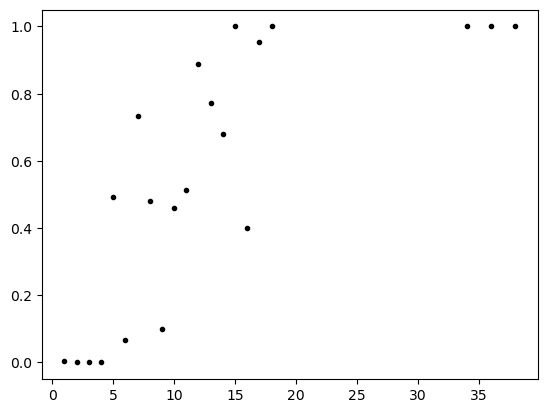

In [14]:
plt.plot(*KS_in_bins(g3grpn,g3logmh,fofgrpn,foflogmh),'k.')

In [15]:
# test manually
ks_2samp(g3logmh[g3grpn==2], foflogmh[fofgrpn==2])

KstestResult(statistic=0.2126424885787365, pvalue=9.411105719991722e-11, statistic_location=11.763901959985745, statistic_sign=-1)

1.0 0.0038772235513318443
2.0 9.411105719991722e-11
3.0 1.2167845498065278e-07
4.0 7.575462766278899e-05
5.0 0.4915910780082645


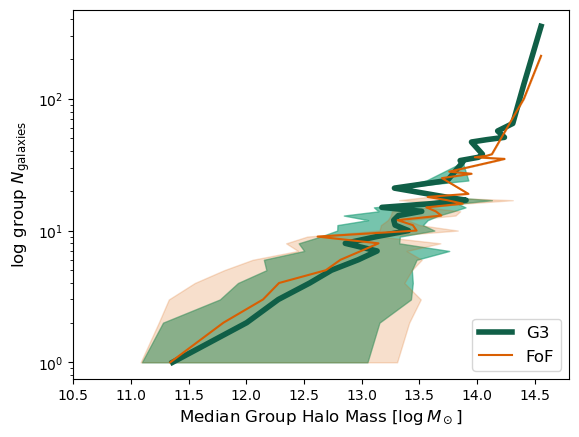

In [16]:
#
plt.figure()
plt.plot(*uniqstat(g3grpn,g3logmh,np.median),color='#105f47',linewidth=4, label='G3')
plt.fill_betweenx(uniqstat(g3grpn,g3logmh,np.min)[1], uniqstat(g3grpn,g3logmh,np.min)[0],\
                 uniqstat(g3grpn,g3logmh,np.max)[0],color='#1b9e77',alpha=0.6)
plt.plot(*uniqstat(fofgrpn,foflogmh,np.median),color='#d95f02', label='FoF')
#plt.plot(uniqstat(fofgrpn,foflogmh,np.min)[0], uniqstat(fofgrpn,foflogmh,np.min)[1],color='#d95f02',alpha=0.6, linestyle='dashed')
plt.fill_betweenx(uniqstat(fofgrpn,foflogmh,np.min)[1], uniqstat(fofgrpn,foflogmh,np.min)[0],\
                 uniqstat(fofgrpn,foflogmh,np.max)[0],color='#d95f02',alpha=0.2)


#uniqstat(fofgrpn,foflogmh,np.max)[0]
plt.gca().set_yscale('log')
plt.xlim(10.5,14.8)
plt.ylabel(r"log group $N_{\rm galaxies}$",fontsize=12)
plt.xlabel(r"Median Group Halo Mass [$\log M_\odot$]",fontsize=12)
plt.legend(loc='lower right',fontsize=12)

nn, pvs = KS_in_bins(g3grpn,g3logmh,fofgrpn,foflogmh)
for ii,yvalue in enumerate(nn):
     if yvalue < 6:
            print(yvalue,pvs[ii])
         #plt.annotate("{:0.3E}".format(pvs[ii]), xy=(10.6,yvalue+0.2*yvalue**2))

plt.show()

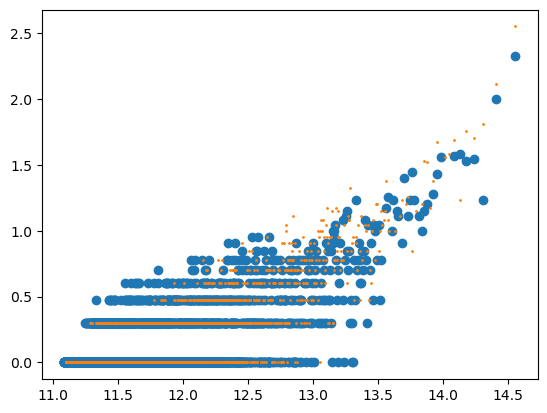

In [17]:
plt.scatter(foflogmh, np.log10(fofgrpn))
plt.scatter(g3logmh, np.log10(g3grpn),s=1)

0.34236178226521924
1.833566415486022
0.6877804041605576
3.9574484545449145
5.290956277724387
6.476120077696278
2.8879817601028672


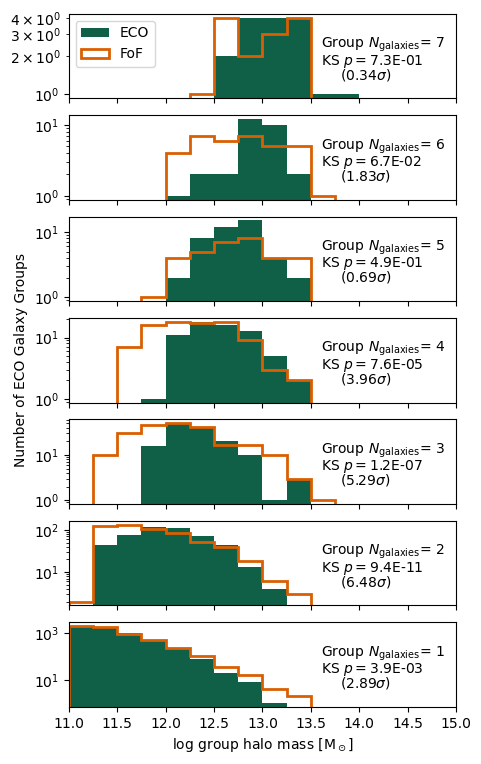

In [18]:
maxN = 7
fig2, axs = plt.subplots(maxN,figsize=(5,9),sharex=True)
binv = np.arange(11,15,0.25)
for ii in range(0,maxN):
    nn = maxN-ii
    g3sel = (g3grpn==nn)
    axs[ii].hist(g3logmh[g3sel],color='#105f47',bins=binv, label='ECO')
    fofsel = (fofgrpn==nn)
    axs[ii].hist(foflogmh[fofsel],color='#d95f02',histtype='step',bins=binv, linewidth=2,label='FoF')
    axs[ii].set_yscale('log')
    axs[ii].annotate(r'Group $N_{\rm galaxies}$'+'= {}'.format(nn),xy=(0.65,0.6),xycoords='axes fraction')
    _, pv = ks_2samp(g3logmh[g3sel],foflogmh[fofsel])
    sigval = norm.ppf(1-(pv)/2.)
    print(sigval)
    axs[ii].annotate(r'KS $p=$'+'{:.1E}'.format(pv), xy=(0.65,0.4), xycoords='axes fraction')
    axs[ii].annotate(r"({:0.2f}".format(sigval)+r"$\sigma$)", xy=(0.7,0.23), xycoords='axes fraction')
    axs[ii].set_xlim(11,15)
axs[0].legend(loc='upper left')
axs[maxN//2].set_ylabel("Number of ECO Galaxy Groups")
axs[maxN-1].set_xlabel(r"log group halo mass [$\rm M_\odot$]")
plt.show()